In [1]:
import json

In [ ]:
FILE_NAME_FORMAT = ('../results/cross_encoder/fine_tuned/'
                    'recall_mrr_results_finetuned_{num_neg}_epochs_{num_epoch}.json')

In [3]:
results = {}

for num_neg in [7, 15, 31] :
    for num_epoch in [100, 1000, 5000] :
        file_name = FILE_NAME_FORMAT.format(num_neg=num_neg, num_epoch=num_epoch)
        with open(file_name, 'r') as f :
            result = json.load(f)

            results[(num_neg, num_epoch)] = result

results[(7, 100)]

{'1': {'recall': 0.8005115089514067, 'mrr': 0.8005115089514067},
 '3': {'recall': 0.948849104859335, 'mrr': 0.8678601875532819},
 '5': {'recall': 0.969309462915601, 'mrr': 0.8727195225916451},
 '10': {'recall': 0.979539641943734, 'mrr': 0.8741403807899969},
 '15': {'recall': 0.979539641943734, 'mrr': 0.8741403807899969},
 '20': {'recall': 0.9872122762148338, 'mrr': 0.8745465790749375}}

In [9]:
import matplotlib.pyplot as plt
import numpy as np

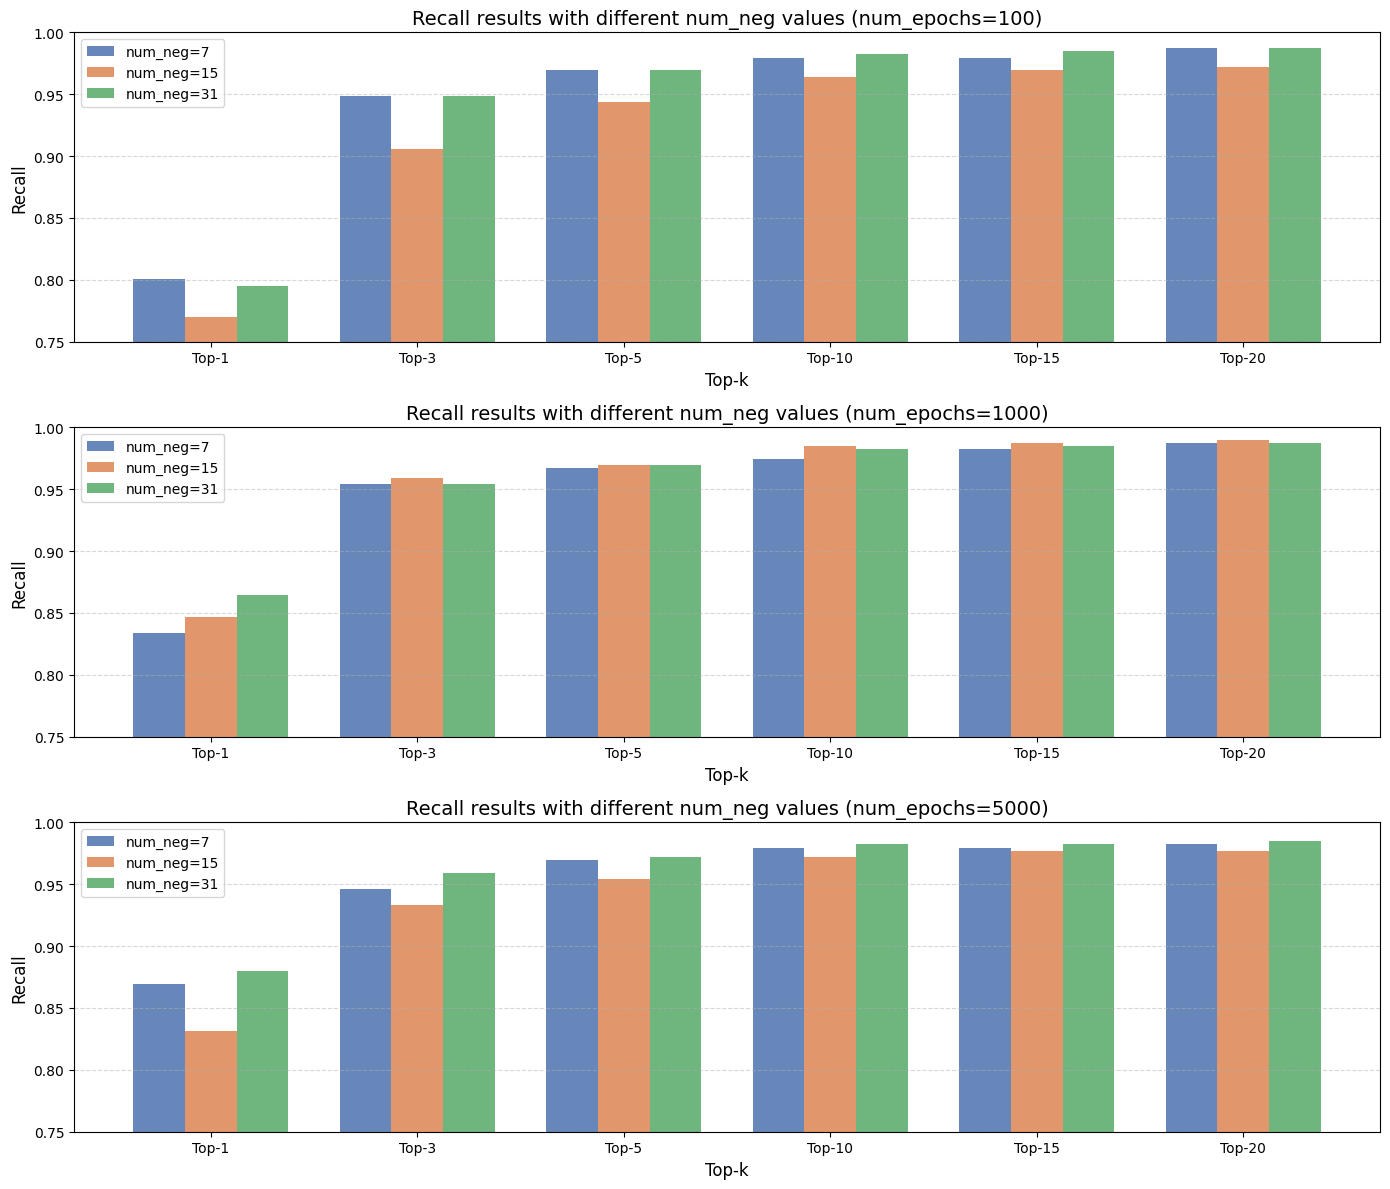

In [17]:
top_ks = [1, 3, 5, 10, 15, 20]
num_negs = [7, 15, 31]
num_epochs_list = [100, 1000, 5000]

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

x = np.arange(len(top_ks))
bar_width = 0.25
colors = ['#4C72B0', '#DD8452', '#55A868']

for i, num_epoch in enumerate(num_epochs_list):
    ax = axes[i]

    for j, num_neg in enumerate(num_negs):
        model_recalls = [results[(num_neg, num_epoch)][str(k)]['recall'] for k in top_ks]
        # improvements = [m - b for m, b in zip(model_recalls, base_recalls)]
        offset = (j - 1) * bar_width
        bars = ax.bar(x + offset, model_recalls, bar_width,
                      label=f'num_neg={num_neg}', color=colors[j], alpha=0.85)

    ax.set_ylim(0.75, 1.0)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Recall results with different num_neg values (num_epochs={num_epoch})', fontsize=14)
    ax.set_xlabel('Top-k', fontsize=12)
    ax.set_ylabel('Recall', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels([f'Top-{k}' for k in top_ks])
    ax.legend(loc='upper left')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../plot/cross_encoder/recall_bar_chart_cross_encoder.svg')
plt.show()


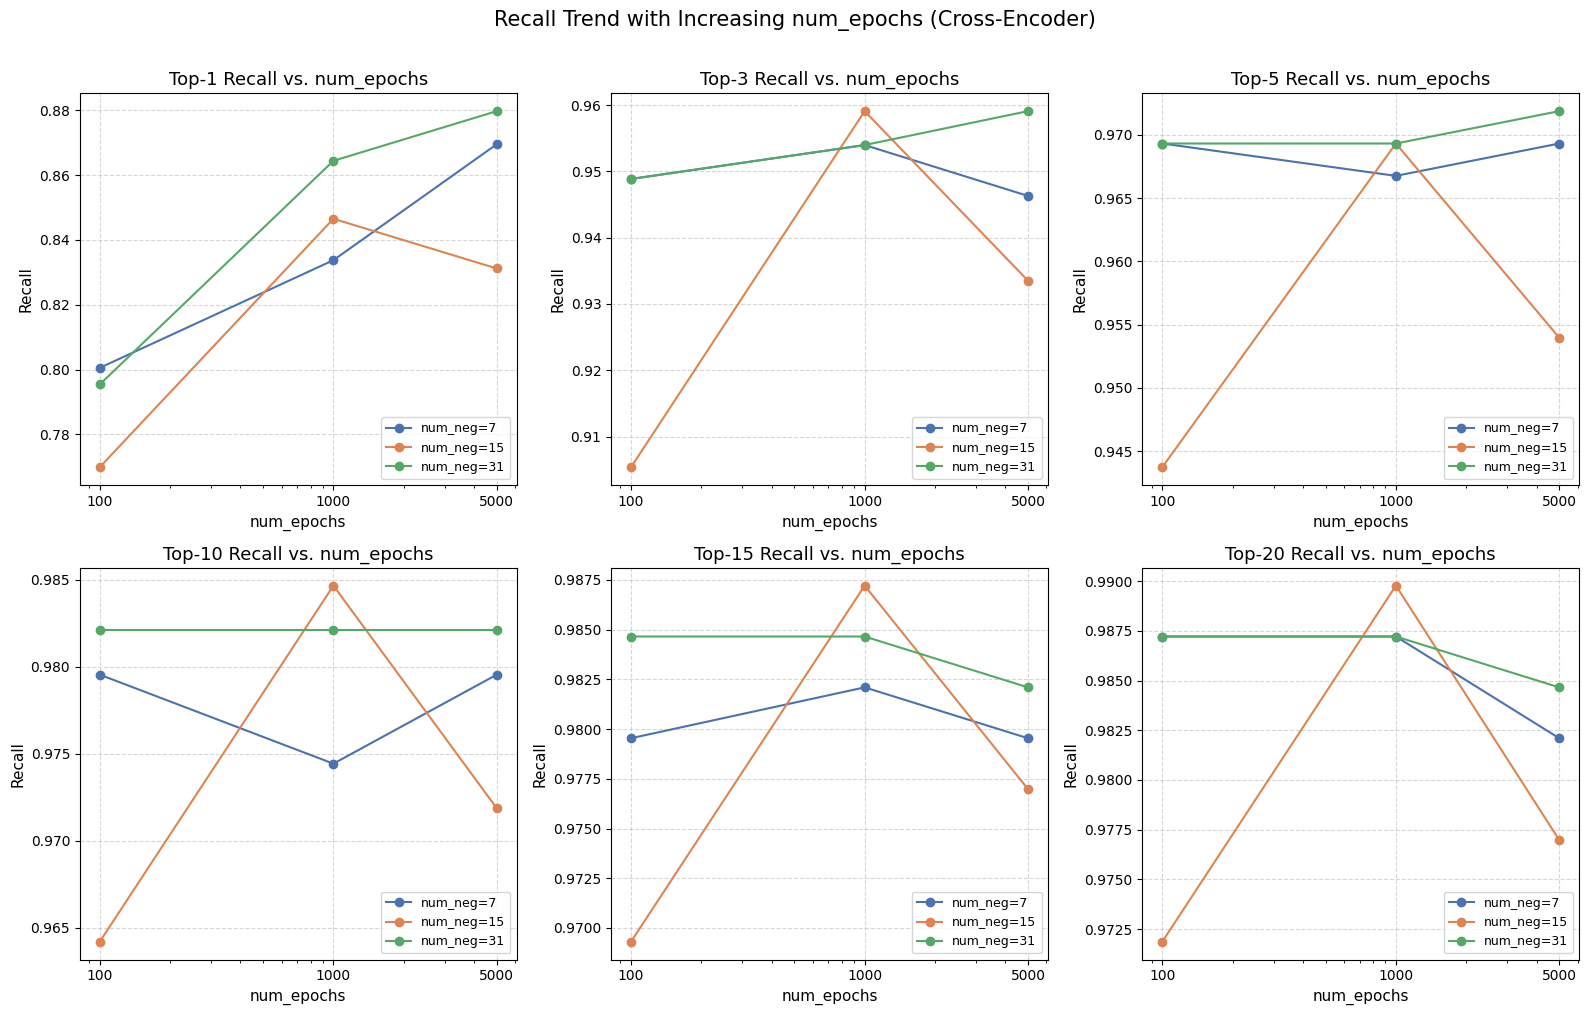

In [ ]:
top_ks = [1, 3, 5, 10, 15, 20]
num_negs = [7, 15, 31]
num_epochs_list = [100, 1000, 5000]
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, top_k in enumerate(top_ks):
    ax = axes[idx]
    for j, num_neg in enumerate(num_negs):
        recalls = [results[(num_neg, num_epoch)][str(top_k)]['recall'] for num_epoch in num_epochs_list]
        ax.plot(num_epochs_list, recalls, marker='o', label=f'num_neg={num_neg}', color=colors[j])

    ax.set_title(f'Top-{top_k} Recall vs. num_epochs', fontsize=13)
    ax.set_xlabel('num_epochs', fontsize=11)
    ax.set_ylabel('Recall', fontsize=11)
    ax.set_xscale('log')
    ax.set_xticks(num_epochs_list)
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(linestyle='--', alpha=0.5)

plt.suptitle('Recall Trend with Increasing num_epochs (Cross-Encoder)', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('../plot/cross_encoder/recall_trend_epochs_cross_encoder.svg', bbox_inches='tight')
plt.show()